# HW3: Simple Structure from Motion
## Two-View Pipeline (SIFT + Essential Matrix + Triangulation)

### Pipeline Overview
1. **Step 1: Camera Intrinsics** (`K`)
2. **Step 2: SIFT Feature Detection**
3. **Step 3: Feature Matching (L2 + NNDR)**
4. **Step 4: RANSAC on Essential Matrix**
5. **Step 5: Triangulate Inliers (Sparse 3D)**

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from intrinsics import compute_K
from features import get_sift_features, match_features
from ransac import RANSAC
from triangulation import triangulate_with_reprojection_filter

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)

## Step 0: Load Input Images

Loaded 2 images from images/input/input1
  1. images/input/input1\img1.jpeg
  2. images/input/input1\img2.jpeg
Pipeline pair (Image 1 / Image 2): images/input/input1\img1.jpeg, images/input/input1\img2.jpeg


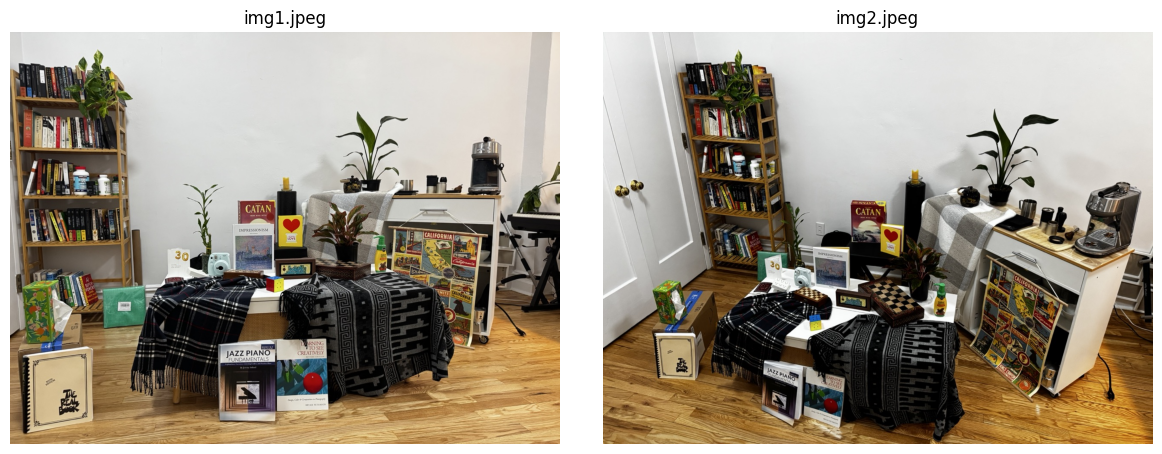

In [13]:
INPUT_DIR = "images/input/input1"
OUTPUT_DIR = "images/output/output1"
os.makedirs(OUTPUT_DIR, exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")
image_paths = sorted(
    [
        os.path.join(INPUT_DIR, f)
        for f in os.listdir(INPUT_DIR)
        if os.path.isfile(os.path.join(INPUT_DIR, f)) and f.lower().endswith(valid_exts)
    ]
)

if len(image_paths) == 0:
    raise FileNotFoundError(f"No images found in {INPUT_DIR}")
if len(image_paths) < 2:
    raise RuntimeError(f"Need at least 2 images in {INPUT_DIR}, found {len(image_paths)}")

# Keep backward-compatible variables for downstream pipeline cells.
IMG1_PATH = image_paths[0]
IMG2_PATH = image_paths[1]
img1 = np.array(Image.open(IMG1_PATH).convert("RGB"))
img2 = np.array(Image.open(IMG2_PATH).convert("RGB"))
img1_gray = np.array(Image.open(IMG1_PATH).convert("L"))
img2_gray = np.array(Image.open(IMG2_PATH).convert("L"))

print(f"Loaded {len(image_paths)} images from {INPUT_DIR}")
for i, p in enumerate(image_paths, start=1):
    print(f"  {i}. {p}")
print(f"Pipeline pair (Image 1 / Image 2): {IMG1_PATH}, {IMG2_PATH}")

# Display all loaded input images.
n_imgs = len(image_paths)
cols = min(3, n_imgs)
rows = int(np.ceil(n_imgs / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4.5 * rows))
axes = np.array(axes).reshape(rows, cols)

for i, path in enumerate(image_paths):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(np.array(Image.open(path).convert("RGB")))
    ax.set_title(os.path.basename(path))
    ax.axis("off")

for j in range(n_imgs, rows * cols):
    r, c = divmod(j, cols)
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()

## Step 1: Compute Camera Intrinsics `K`

In [3]:
optical_focal_length_mm = 6.765
sensor_width_mm = 9.757
sensor_height_mm = 7.318

h_px, w_px = img1_gray.shape
K = compute_K(
    img_width_px=w_px,
    img_height_px=h_px,
    optical_focal_length_mm=optical_focal_length_mm,
    sensor_width_mm=sensor_width_mm,
    sensor_height_mm=sensor_height_mm,
)

print("Camera intrinsic matrix K:")
print(K)

Camera intrinsic matrix K:
[[887.47074826   0.         640.        ]
 [  0.         887.47074826 480.        ]
 [  0.           0.           1.        ]]


## Step 2: SIFT Feature Detection

SIFT features: image1=3992, image2=3986


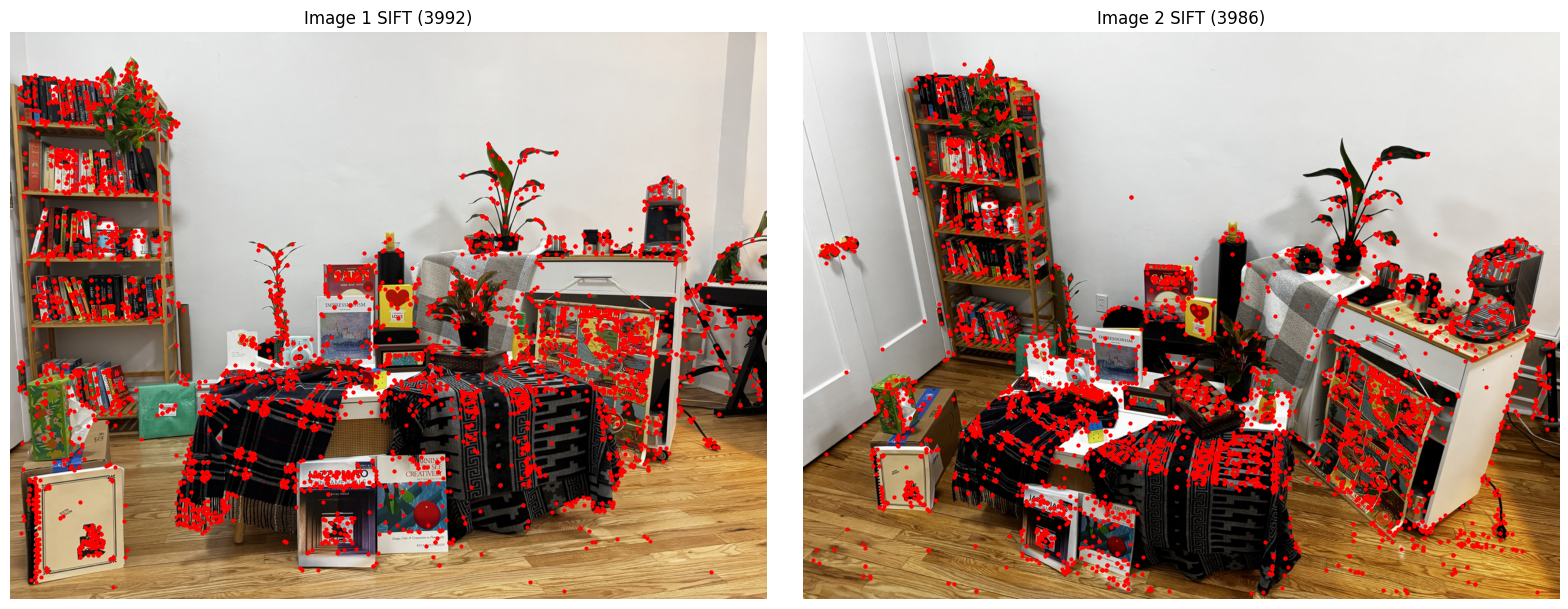

Saved: images/output/hw3\step2_sift_keypoints.png
Saved: images/output/hw3\step2_sift_stats.txt


In [4]:
sift_max_features = 4000
sift_edge_discard = 10
sift_contrast_threshold = 0.04
sift_edge_threshold = 10
sift_n_octave_layers = 3
sift_sigma = 1.6

corners1, desc1, resp1 = get_sift_features(
    img1_gray,
    edge_discard=sift_edge_discard,
    max_features=sift_max_features,
    contrast_threshold=sift_contrast_threshold,
    edge_threshold=sift_edge_threshold,
    n_octave_layers=sift_n_octave_layers,
    sigma=sift_sigma,
)

corners2, desc2, resp2 = get_sift_features(
    img2_gray,
    edge_discard=sift_edge_discard,
    max_features=sift_max_features,
    contrast_threshold=sift_contrast_threshold,
    edge_threshold=sift_edge_threshold,
    n_octave_layers=sift_n_octave_layers,
    sigma=sift_sigma,
)

keypoints1 = corners1.T
keypoints2 = corners2.T

num_sift_1 = int(keypoints1.shape[0])
num_sift_2 = int(keypoints2.shape[0])
print(f"SIFT features: image1={num_sift_1}, image2={num_sift_2}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(img1)
if num_sift_1 > 0:
    axes[0].scatter(keypoints1[:, 1], keypoints1[:, 0], s=4, c='r')
axes[0].set_title(f"Image 1 SIFT ({num_sift_1})")
axes[0].axis("off")

axes[1].imshow(img2)
if num_sift_2 > 0:
    axes[1].scatter(keypoints2[:, 1], keypoints2[:, 0], s=4, c='r')
axes[1].set_title(f"Image 2 SIFT ({num_sift_2})")
axes[1].axis("off")
plt.tight_layout()

sift_vis_path = os.path.join(OUTPUT_DIR, "step2_sift_keypoints.png")
plt.savefig(sift_vis_path, dpi=220, bbox_inches='tight')
plt.show()
print("Saved:", sift_vis_path)

step2_stats_path = os.path.join(OUTPUT_DIR, "step2_sift_stats.txt")
with open(step2_stats_path, "w", encoding="utf-8") as f:
    f.write(f"sift_max_features={sift_max_features}\n")
    f.write(f"sift_edge_discard={sift_edge_discard}\n")
    f.write(f"sift_contrast_threshold={sift_contrast_threshold}\n")
    f.write(f"sift_edge_threshold={sift_edge_threshold}\n")
    f.write(f"sift_n_octave_layers={sift_n_octave_layers}\n")
    f.write(f"sift_sigma={sift_sigma}\n")
    f.write(f"num_sift_image1={num_sift_1}\n")
    f.write(f"num_sift_image2={num_sift_2}\n")
print("Saved:", step2_stats_path)

## Step 3: Feature Matching (L2 + NNDR)

Correspondences after NNDR: 395


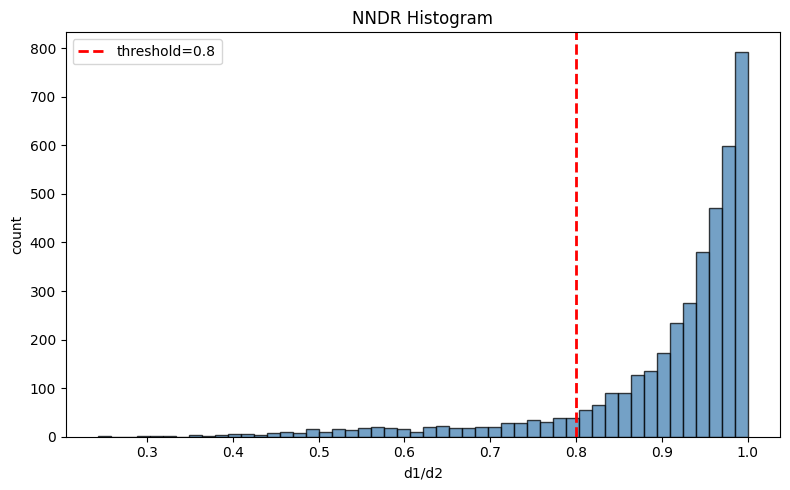

Saved: images/output/hw3\nndr_histogram.png


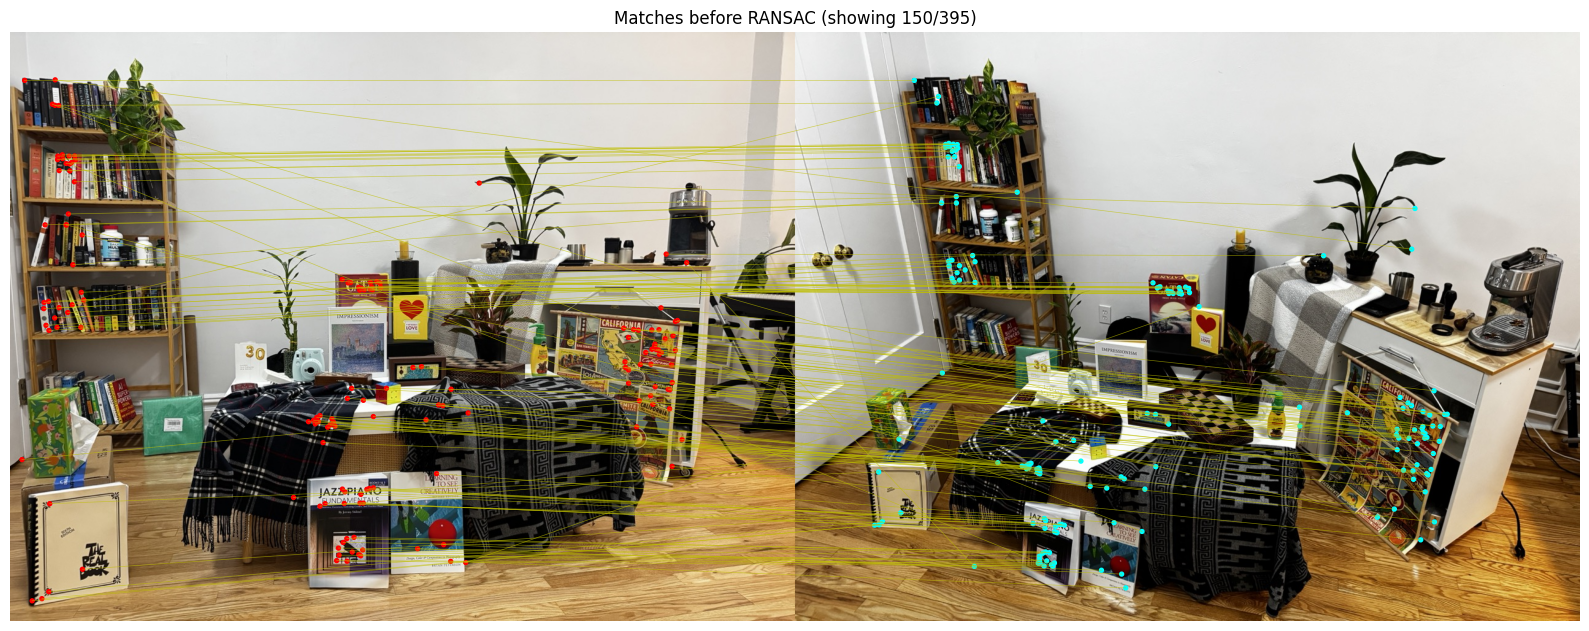

Saved: images/output/hw3\matches_before_ransac.png


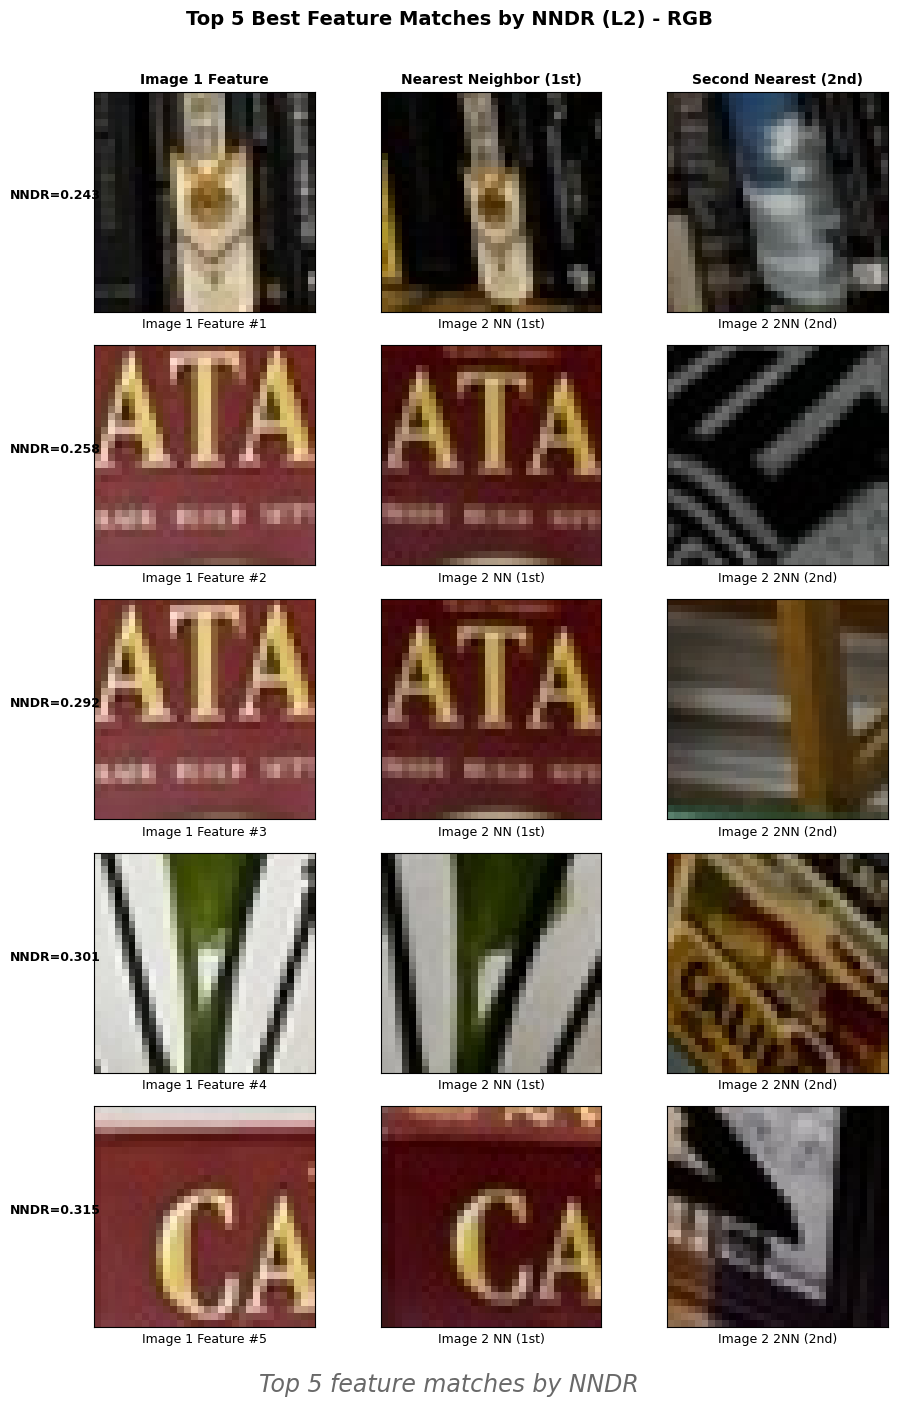

Saved: images/output/hw3\nndr_top5_matches.png
Saved: images/output/hw3\step3_matching_stats.txt


In [5]:
ratio_threshold = 0.8
correspondence_pairs, knn_matches, nndr = match_features(
    desc1, desc2, keypoints1, keypoints2, ratio_threshold=ratio_threshold
)

num_corr = len(correspondence_pairs)
print(f"Correspondences after NNDR: {num_corr}")

step3_stats = [
    f"ratio_threshold={ratio_threshold}",
    f"num_correspondences_after_nndr={num_corr}",
]

# NNDR histogram
if len(nndr) > 0:
    plt.figure(figsize=(8, 5))
    plt.hist(nndr, bins=50, color='steelblue', edgecolor='black', alpha=0.75)
    plt.axvline(ratio_threshold, color='red', linestyle='--', linewidth=2, label=f"threshold={ratio_threshold}")
    plt.title("NNDR Histogram")
    plt.xlabel("d1/d2")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    nndr_hist_path = os.path.join(OUTPUT_DIR, "nndr_histogram.png")
    plt.savefig(nndr_hist_path, dpi=220, bbox_inches='tight')
    plt.show()

    step3_stats.extend([
        f"nndr_count={len(nndr)}",
        f"nndr_min={float(np.min(nndr)):.6f}",
        f"nndr_mean={float(np.mean(nndr)):.6f}",
        f"nndr_median={float(np.median(nndr)):.6f}",
        f"nndr_max={float(np.max(nndr)):.6f}",
    ])
    print("Saved:", nndr_hist_path)
else:
    print("No NNDR values available for histogram.")

# Matches before RANSAC (also saved)
fig, ax = plt.subplots(figsize=(16, 7))
combined = np.hstack([img1, img2])
ax.imshow(combined)
_, w1 = img1.shape[:2]
plot_n = min(num_corr, 150)
for i in range(plot_n):
    y1, x1 = correspondence_pairs[i, 0]
    y2, x2 = correspondence_pairs[i, 1]
    x2s = x2 + w1
    ax.plot([x1, x2s], [y1, y2], 'y-', linewidth=0.5, alpha=0.6)
    ax.scatter([x1, x2s], [y1, y2], s=8, c=['red', 'cyan'])
ax.set_title(f"Matches before RANSAC (showing {plot_n}/{num_corr})")
ax.axis("off")
plt.tight_layout()
matches_before_path = os.path.join(OUTPUT_DIR, "matches_before_ransac.png")
plt.savefig(matches_before_path, dpi=220, bbox_inches='tight')
plt.show()
print("Saved:", matches_before_path)

# --- Top 5 feature descriptors by NNDR (lowest ratio is best) ---
def extract_patch(image, row, col, half_size=16):
    r = int(round(row))
    c = int(round(col))
    padded = np.pad(
        image,
        ((half_size, half_size), (half_size, half_size), (0, 0)),
        mode='reflect',
    )
    patch = padded[r : r + 2 * half_size, c : c + 2 * half_size]
    return patch

scored_matches = []
for pair in knn_matches:
    if len(pair) < 2:
        continue
    m, n = pair
    if n.distance <= 0:
        continue
    ratio = m.distance / n.distance
    scored_matches.append((ratio, m, n))

if len(scored_matches) == 0:
    print("No valid NNDR pairs available for top-5 descriptor visualization.")
    step3_stats.append("top_k_nndr=0")
else:
    scored_matches.sort(key=lambda x: x[0])
    top_k = min(5, len(scored_matches))
    top_matches = scored_matches[:top_k]
    step3_stats.append(f"top_k_nndr={top_k}")

    fig, axes = plt.subplots(top_k, 3, figsize=(10, 2.8 * top_k))
    if top_k == 1:
        axes = np.array([axes])

    col_titles = ["Image 1 Feature", "Nearest Neighbor (1st)", "Second Nearest (2nd)"]
    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=10, fontweight='bold')

    top_ratios = []
    for i, (ratio, m, n) in enumerate(top_matches, start=1):
        top_ratios.append(ratio)
        y1, x1 = keypoints1[m.queryIdx]
        y2a, x2a = keypoints2[m.trainIdx]
        y2b, x2b = keypoints2[n.trainIdx]

        p1 = extract_patch(img1, y1, x1, half_size=16)
        p2a = extract_patch(img2, y2a, x2a, half_size=16)
        p2b = extract_patch(img2, y2b, x2b, half_size=16)

        row_idx = i - 1
        axes[row_idx, 0].imshow(p1)
        axes[row_idx, 1].imshow(p2a)
        axes[row_idx, 2].imshow(p2b)

        axes[row_idx, 0].set_ylabel(f"NNDR={ratio:.3f}", fontsize=9, fontweight='bold', rotation=0, labelpad=28)
        axes[row_idx, 0].set_xlabel(f"Image 1 Feature #{i}", fontsize=9)
        axes[row_idx, 1].set_xlabel("Image 2 NN (1st)", fontsize=9)
        axes[row_idx, 2].set_xlabel("Image 2 2NN (2nd)", fontsize=9)

        for j in range(3):
            axes[row_idx, j].set_xticks([])
            axes[row_idx, j].set_yticks([])

    fig.suptitle("Top 5 Best Feature Matches by NNDR (L2) - RGB", fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0.02, 0.03, 1, 0.985])
    plt.figtext(0.5, 0.008, "Top 5 feature matches by NNDR", ha='center', fontsize=17, style='italic', color='dimgray')
    top_matches_path = os.path.join(OUTPUT_DIR, "nndr_top5_matches.png")
    plt.savefig(top_matches_path, dpi=220, bbox_inches='tight')
    plt.show()
    print("Saved:", top_matches_path)

    step3_stats.append("top_ratios=" + ",".join([f"{r:.6f}" for r in top_ratios]))

step3_stats_path = os.path.join(OUTPUT_DIR, "step3_matching_stats.txt")
with open(step3_stats_path, "w", encoding="utf-8") as f:
    f.write("\n".join(step3_stats) + "\n")
print("Saved:", step3_stats_path)

## Step 4: RANSAC on Essential Matrix

RANSAC inliers: 312/395
R:
[[ 0.91364672 -0.07145576  0.40017964]
 [ 0.18296591  0.95136337 -0.24785322]
 [-0.36300571  0.29966951  0.88228399]]
t:
[-0.7778295   0.53718549  0.32621008]


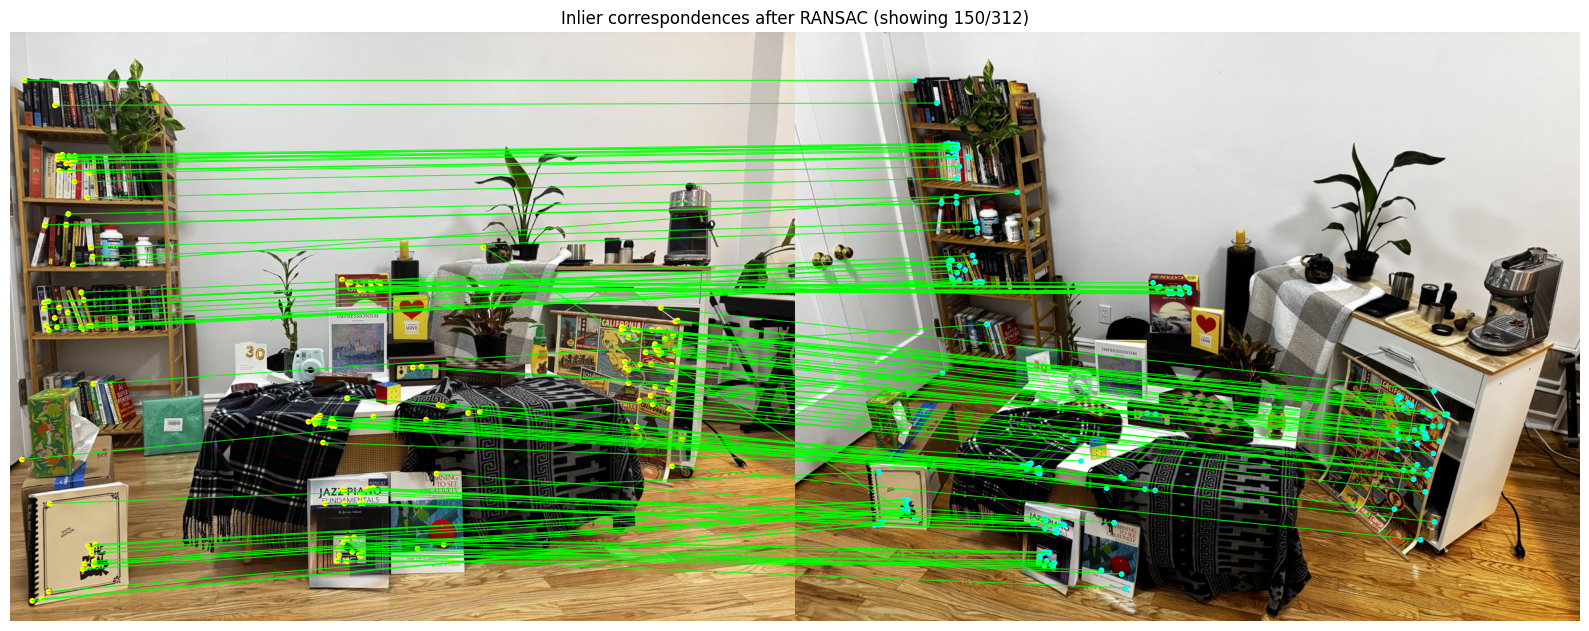

Saved: images/output/hw3\ransac_inlier_matches.png


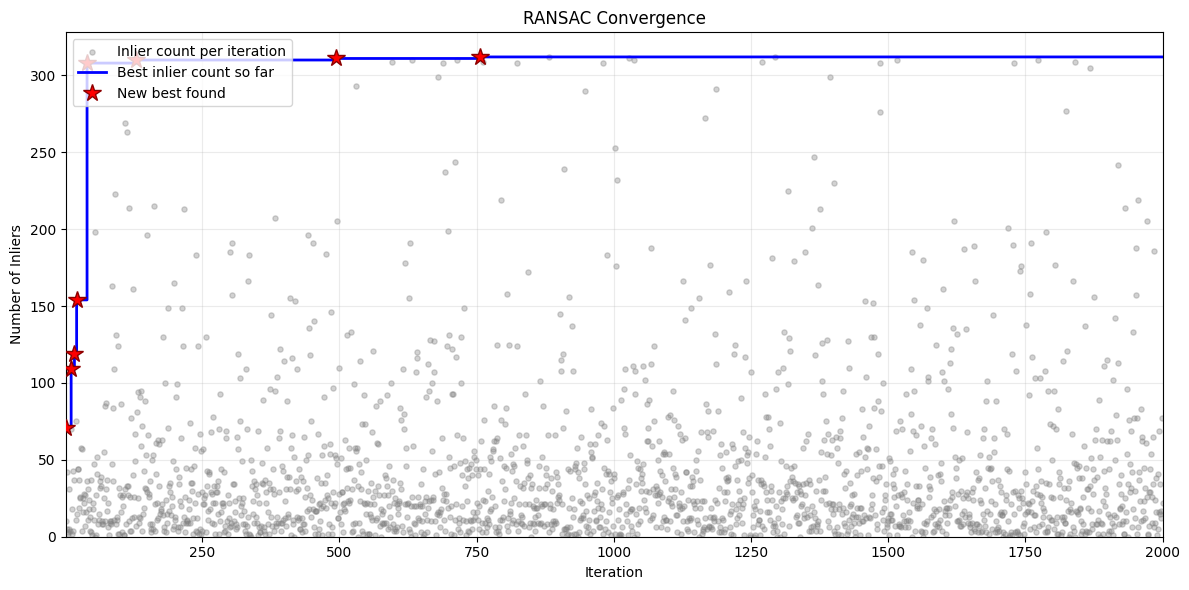

Saved: images/output/hw3\ransac_convergence.png
Saved: images/output/hw3\step4_ransac_stats.txt


In [6]:
ransac_s = 8
ransac_epsilon = 2e-4
ransac_num_iters = 2000

ransac_result = RANSAC(
    correspondence_pairs=correspondence_pairs,
    K=K,
    s=ransac_s,
    epsilon=ransac_epsilon,
    num_iters=ransac_num_iters,
    output_dir=OUTPUT_DIR,
)

# Backward-compatible unpacking: supports old (5/6) and new (7) return signatures.
if ransac_result is None:
    raise RuntimeError("RANSAC returned None")
if len(ransac_result) == 7:
    R, t, inliers_mask, E, points_3d_ransac, ransac_best_inlier_history, ransac_inlier_count_history = ransac_result
elif len(ransac_result) == 6:
    R, t, inliers_mask, E, points_3d_ransac, ransac_best_inlier_history = ransac_result
    ransac_inlier_count_history = None
elif len(ransac_result) == 5:
    R, t, inliers_mask, E, points_3d_ransac = ransac_result
    ransac_best_inlier_history = None
    ransac_inlier_count_history = None
else:
    raise RuntimeError(f"Unexpected RANSAC return length: {len(ransac_result)}")

if R is None:
    raise RuntimeError("RANSAC failed to recover a valid pose")

inlier_correspondences = correspondence_pairs[inliers_mask]
num_inliers = int(np.sum(inliers_mask))
print(f"RANSAC inliers: {num_inliers}/{len(correspondence_pairs)}")
print("R:")
print(R)
print("t:")
print(t)

# Inlier correspondences visualization
fig, ax = plt.subplots(figsize=(16, 7))
combined = np.hstack([img1, img2])
ax.imshow(combined)
_, w1 = img1.shape[:2]
plot_n = min(num_inliers, 150)
for i in range(plot_n):
    y1, x1 = inlier_correspondences[i, 0]
    y2, x2 = inlier_correspondences[i, 1]
    x2s = x2 + w1
    ax.plot([x1, x2s], [y1, y2], 'lime', linewidth=0.8, alpha=0.8)
    ax.scatter([x1, x2s], [y1, y2], s=10, c=['yellow', 'cyan'])
ax.set_title(f"Inlier correspondences after RANSAC (showing {plot_n}/{num_inliers})")
ax.axis("off")
plt.tight_layout()
ransac_matches_path = os.path.join(OUTPUT_DIR, "ransac_inlier_matches.png")
plt.savefig(ransac_matches_path, dpi=220, bbox_inches='tight')
plt.show()
print("Saved:", ransac_matches_path)

# RANSAC convergence plot: per-iteration inlier counts and best-so-far progression
if ransac_best_inlier_history is not None and len(ransac_best_inlier_history) > 0:
    best_hist = np.asarray(ransac_best_inlier_history, dtype=int)
    iters = np.arange(1, len(best_hist) + 1)

    raw_hist = None
    if ransac_inlier_count_history is not None and len(ransac_inlier_count_history) == len(best_hist):
        raw_hist = np.asarray(ransac_inlier_count_history, dtype=int)

    fig, ax = plt.subplots(figsize=(12, 6))
    if raw_hist is not None:
        ax.scatter(
            iters,
            raw_hist,
            s=14,
            color='gray',
            alpha=0.35,
            label='Inlier count per iteration',
            zorder=1,
        )

    ax.step(
        iters,
        best_hist,
        where='post',
        color='blue',
        linewidth=2.0,
        label='Best inlier count so far',
        zorder=2,
    )

    new_best_mask = np.r_[True, np.diff(best_hist) > 0]
    ax.plot(
        iters[new_best_mask],
        best_hist[new_best_mask],
        linestyle='None',
        marker='*',
        markersize=13,
        color='red',
        markeredgecolor='darkred',
        label='New best found',
        zorder=3,
    )

    y_max = int(np.max(best_hist))
    if raw_hist is not None:
        y_max = max(y_max, int(np.max(raw_hist)))

    ax.set_title("RANSAC Convergence")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Number of Inliers")
    ax.set_xlim(1, len(iters))
    ax.set_ylim(0, max(5, int(np.ceil(1.05 * y_max))))
    ax.grid(alpha=0.25)
    ax.legend(loc='upper left')
    plt.tight_layout()

    ransac_conv_path = os.path.join(OUTPUT_DIR, "ransac_convergence.png")
    plt.savefig(ransac_conv_path, dpi=220, bbox_inches='tight')
    plt.show()
    print("Saved:", ransac_conv_path)
else:
    ransac_conv_path = None
    print("No RANSAC convergence history available.")

step4_stats = [
    f"ransac_sample_size={ransac_s}",
    f"ransac_epsilon={ransac_epsilon}",
    f"ransac_num_iters={ransac_num_iters}",
    f"total_correspondences={len(correspondence_pairs)}",
    f"num_inliers={num_inliers}",
    f"inlier_ratio={num_inliers / max(1, len(correspondence_pairs)):.6f}",
]
if ransac_best_inlier_history is not None and len(ransac_best_inlier_history) > 0:
    step4_stats.append(f"best_inliers_last_iter={int(ransac_best_inlier_history[-1])}")
    step4_stats.append(f"convergence_iterations_recorded={len(ransac_best_inlier_history)}")
if ransac_inlier_count_history is not None and len(ransac_inlier_count_history) > 0:
    step4_stats.append(f"per_iteration_counts_recorded={len(ransac_inlier_count_history)}")
step4_stats_path = os.path.join(OUTPUT_DIR, "step4_ransac_stats.txt")
with open(step4_stats_path, "w", encoding="utf-8") as f:
    f.write("\n".join(step4_stats) + "\n")
print("Saved:", step4_stats_path)

## Step 5: Triangulate Inliers (Sparse 3D Point Cloud)

Triangulated: 312, valid: 312
Final valid 3D points: 312
Reprojection error stats (all): min=0.00, mean=2.60, median=2.28, max=10.91


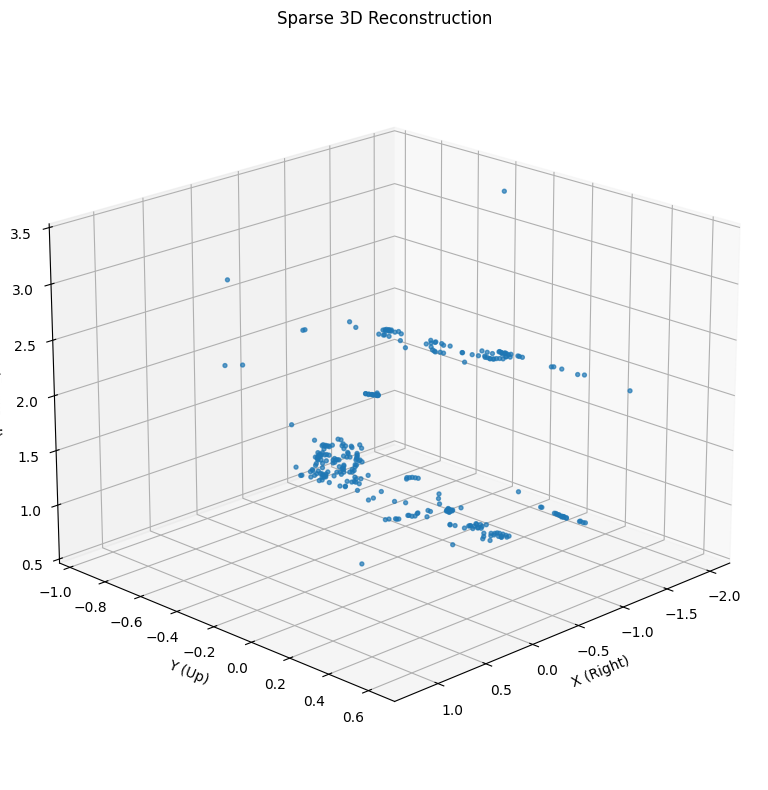

In [7]:
inlier_pts1 = inlier_correspondences[:, 0]
inlier_pts2 = inlier_correspondences[:, 1]

points_3d, valid_3d_mask_subset, reproj_errors = triangulate_with_reprojection_filter(
    R, t, inlier_pts1, inlier_pts2, K,
    max_reprojection_error=50.0,
    min_depth=0.01,
    max_depth=10000.0,
    verbose=True,
)

print(f"Final valid 3D points: {len(points_3d)}")
if len(reproj_errors) > 0:
    print(
        f"Reprojection error stats (all): "
        f"min={reproj_errors.min():.2f}, "
        f"mean={reproj_errors.mean():.2f}, "
        f"median={np.median(reproj_errors):.2f}, "
        f"max={reproj_errors.max():.2f}"
    )

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
if len(points_3d) > 0:
    ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=8, alpha=0.7)
ax.set_xlabel("X (Right)")
ax.set_ylabel("Y (Up)")
ax.set_zlabel("Z (Forward)")
ax.set_title("Sparse 3D Reconstruction")
ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

# 3 Triangulation Views (with Cameras + Captions)

Saves three screenshots in `images/output/hw3/`:
- both cameras visible in each view
- sparse point cloud from different angles
- caption text below each subplot

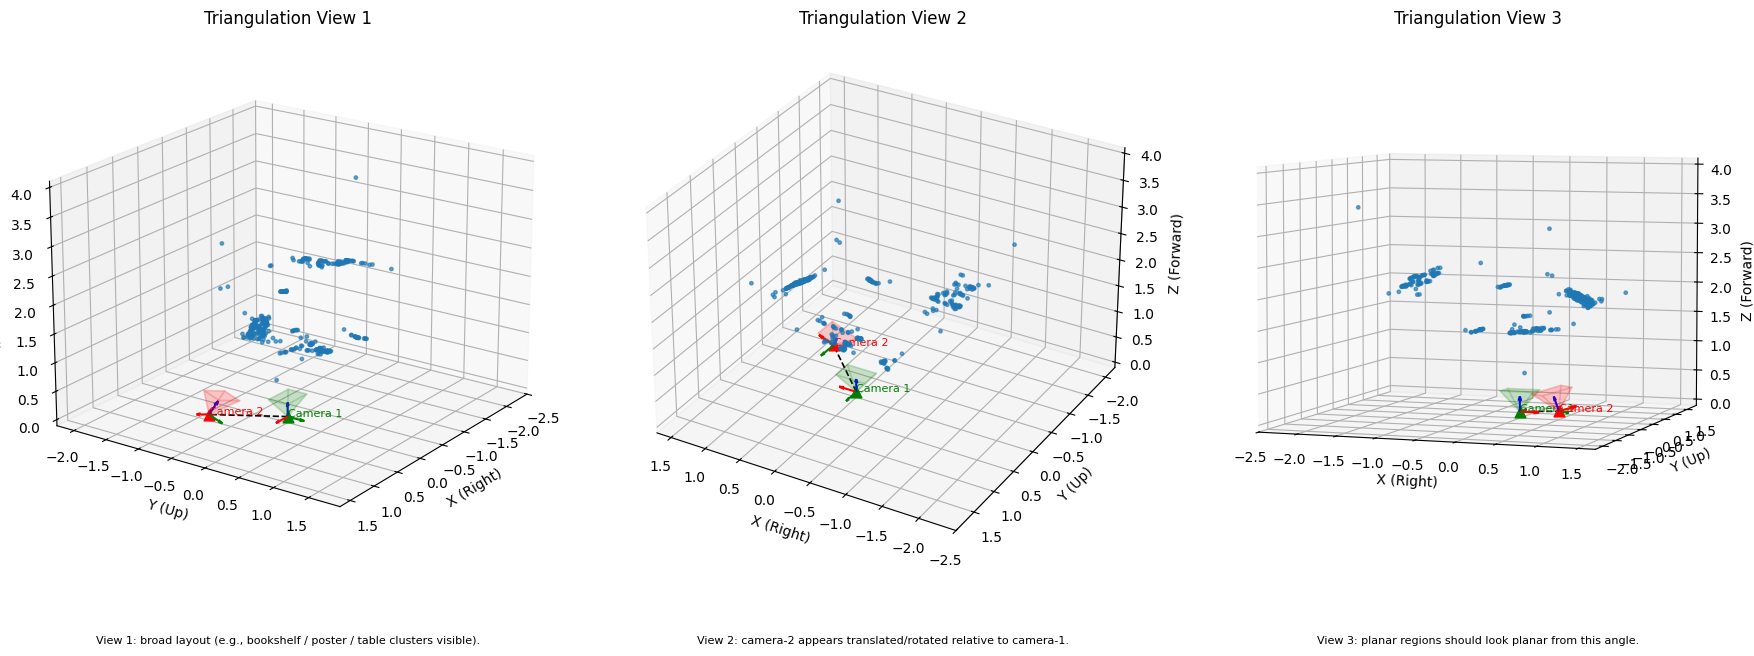

Saved:
 - images/output/hw3\triangulation_3views_with_cameras.png
 - images/output/hw3\triangulation_view_1.png
 - images/output/hw3\triangulation_view_2.png
 - images/output/hw3\triangulation_view_3.png


In [8]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def camera_center_from_rt(R_wc, t_wc):
    return -R_wc.T @ t_wc


def build_frustum(C, R_c2w, scale=0.25):
    # Local camera frustum corners in camera coordinates
    # OpenCV convention: +Z forward
    z = 1.0 * scale
    w = 0.6 * scale
    h = 0.4 * scale
    corners_cam = np.array([
        [0, 0, 0],
        [-w, -h, z],
        [ w, -h, z],
        [ w,  h, z],
        [-w,  h, z],
    ])
    corners_world = (R_c2w @ corners_cam.T).T + C
    return corners_world


def draw_camera(ax, C, R_c2w, color='green', name='Camera'):
    fr = build_frustum(C, R_c2w, scale=0.35)
    apex = fr[0]
    base = fr[1:]

    # Pyramid faces
    faces = [
        [apex, base[0], base[1]],
        [apex, base[1], base[2]],
        [apex, base[2], base[3]],
        [apex, base[3], base[0]],
        [base[0], base[1], base[2], base[3]],
    ]
    poly = Poly3DCollection(faces, alpha=0.10, facecolor=color, edgecolor=color, linewidths=1.2)
    ax.add_collection3d(poly)

    ax.scatter(*C, color=color, s=60, marker='^')
    ax.text(C[0], C[1], C[2], name, color=color, fontsize=8)

    # Camera axes
    axis_len = 0.25
    ax.quiver(*C, *(R_c2w[:, 0] * axis_len), color='r', linewidth=1.5)  # +X
    ax.quiver(*C, *(R_c2w[:, 1] * axis_len), color='g', linewidth=1.5)  # +Y
    ax.quiver(*C, *(R_c2w[:, 2] * axis_len), color='b', linewidth=1.5)  # +Z


# Camera 1 (reference) in world = identity
C0 = np.zeros(3)
R0_c2w = np.eye(3)

# Camera 2 from recovered [R|t] (world->cam2), convert to c2w
C1 = camera_center_from_rt(R, t)
R1_c2w = R.T

views = [
    (20, 35,  "View 1: broad layout (e.g., bookshelf / poster / table clusters visible)."),
    (30, 120, "View 2: camera-2 appears translated/rotated relative to camera-1."),
    (5,  -70, "View 3: planar regions should look planar from this angle."),
]

fig = plt.figure(figsize=(18, 6))
for idx, (elev, azim, caption) in enumerate(views, start=1):
    ax = fig.add_subplot(1, 3, idx, projection='3d')

    if len(points_3d) > 0:
        ax.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=6, alpha=0.65)

    draw_camera(ax, C0, R0_c2w, color='green', name='Camera 1')
    draw_camera(ax, C1, R1_c2w, color='red', name='Camera 2')

    # Baseline line
    ax.plot([C0[0], C1[0]], [C0[1], C1[1]], [C0[2], C1[2]], 'k--', linewidth=1.2)

    ax.set_title(f"Triangulation View {idx}")
    ax.set_xlabel('X (Right)')
    ax.set_ylabel('Y (Up)')
    ax.set_zlabel('Z (Forward)')
    ax.view_init(elev=elev, azim=azim)

    # Equal-ish axis scaling
    if len(points_3d) > 0:
        mins = np.min(points_3d, axis=0)
        maxs = np.max(points_3d, axis=0)
        ctr = (mins + maxs) / 2.0
        r = np.max(maxs - mins) / 2.0 + 0.5
        ax.set_xlim(ctr[0] - r, ctr[0] + r)
        ax.set_ylim(ctr[1] - r, ctr[1] + r)
        ax.set_zlim(ctr[2] - r, ctr[2] + r)

    ax.text2D(0.5, -0.15, caption, transform=ax.transAxes, ha='center', fontsize=8)

plt.tight_layout()
combined_path = os.path.join(OUTPUT_DIR, 'triangulation_3views_with_cameras.png')
plt.savefig(combined_path, dpi=220, bbox_inches='tight')
plt.show()

# Also save individual views for report insertion
for idx, (elev, azim, caption) in enumerate(views, start=1):
    fig_i = plt.figure(figsize=(7, 6))
    ax_i = fig_i.add_subplot(111, projection='3d')
    if len(points_3d) > 0:
        ax_i.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2], s=8, alpha=0.7)
    draw_camera(ax_i, C0, R0_c2w, color='green', name='Camera 1')
    draw_camera(ax_i, C1, R1_c2w, color='red', name='Camera 2')
    ax_i.plot([C0[0], C1[0]], [C0[1], C1[1]], [C0[2], C1[2]], 'k--', linewidth=1.2)
    ax_i.set_title(f"Triangulation View {idx}")
    ax_i.set_xlabel('X (Right)')
    ax_i.set_ylabel('Y (Up)')
    ax_i.set_zlabel('Z (Forward)')
    ax_i.view_init(elev=elev, azim=azim)
    ax_i.text2D(0.5, -0.10, caption, transform=ax_i.transAxes, ha='center', fontsize=9)
    path_i = os.path.join(OUTPUT_DIR, f'triangulation_view_{idx}.png')
    plt.savefig(path_i, dpi=220, bbox_inches='tight')
    plt.close(fig_i)

print('Saved:')
print(' -', combined_path)
for idx in range(1, 4):
    print(' -', os.path.join(OUTPUT_DIR, f'triangulation_view_{idx}.png'))

## Export Scene for Viser

In [9]:
# Build camera poses (camera-to-world) from recovered R,t
T0 = np.eye(4)
T1 = np.eye(4)
T1[:3, :3] = R.T
T1[:3, 3] = (-R.T @ t).flatten()
camera_poses = np.stack([T0, T1])

# Keep colors for valid triangulated points using image-1 correspondences
valid_corr = inlier_correspondences[valid_3d_mask_subset]
point_colors = []
for pt in valid_corr[:, 0, :]:
    y, x = int(pt[0]), int(pt[1])
    y = np.clip(y, 0, img1.shape[0] - 1)
    x = np.clip(x, 0, img1.shape[1] - 1)
    point_colors.append(img1[y, x, :3])
point_colors = np.array(point_colors)

baseline = float(np.linalg.norm(t))
scene_npz = os.path.join(OUTPUT_DIR, "step5_scene_data.npz")
np.savez(
    scene_npz,
    points_3d=points_3d,
    point_colors=point_colors,
    camera_poses=camera_poses,
    K=K,
    R=R,
    t=t,
    img1=img1,
    img2=img2,
    num_inliers=int(np.sum(inliers_mask)),
    baseline=baseline,
)

print("Saved scene file:", scene_npz)
print("Run this for Viser screenshots:")
print(f"python visualize_viser.py {scene_npz}")
print("\nScreenshot checklist:")
print("1) Keep Point Cloud + Cameras + Camera Images visible")
print("2) Take 3 different view angles")
print("3) Add captions naming landmarks visible in each screenshot")

Saved scene file: images/output/hw3\step5_scene_data.npz
Run this for Viser screenshots:
python visualize_viser.py images/output/hw3\step5_scene_data.npz

Screenshot checklist:
1) Keep Point Cloud + Cameras + Camera Images visible
2) Take 3 different view angles
3) Add captions naming landmarks visible in each screenshot


## Interactive Viser Viewer

In [10]:
from visualize_viser import visualize_scene

In [11]:
# Run after the scene export cell has created `scene_npz`
server = visualize_scene(scene_npz, port=8081, block=False)
server

╭────── viser (listening *:8081) ───────╮
│             ╷                         │
│   HTTP      │ http://localhost:8081   │
│   Websocket │ ws://localhost:8081     │
│             ╵                         │
╰───────────────────────────────────────╯

Viser running at: http://localhost:8081
Open the URL above in your browser.


## Auto Captions for Viser Screenshots

Generate caption text for your 3 Viser screenshots (copy-paste into report).
You can optionally provide landmark hints for each screenshot.

In [12]:
from visualize_viser import generate_viser_captions_from_folder

npz_path = scene_npz if "scene_npz" in globals() else os.path.join(OUTPUT_DIR, "step5_scene_data.npz")
viser_dir = os.path.join(OUTPUT_DIR, "viser")

# Optional: edit based on what you see in each screenshot (in sorted file order).
landmark_hints = [
    "bookshelf, poster, coffee table",
    "camera 2 shifted top-right",
    "poster plane",
]

viser_captions, captions_out = generate_viser_captions_from_folder(
    npz_path=npz_path,
    viser_dir=viser_dir,
    landmark_hints=landmark_hints,
    output_filename="viser_screenshot_captions.txt",
)

viser_captions

Screenshot 1 (image1.png): ... moderate detail; scene is well centered in frame. I see bookshelf, poster, coffee table.
Screenshot 2 (image2.png): ... camera 2 appears right, lower and forward; pose looks consistent. I see camera 2 shifted top-right.
Screenshot 3 (image3.png): ... structure looks more volumetric; scene sits compactly in frame. I see poster plane.

Saved caption file: images/output/hw3\viser\viser_screenshot_captions.txt


['... moderate detail; scene is well centered in frame. I see bookshelf, poster, coffee table.',
 '... camera 2 appears right, lower and forward; pose looks consistent. I see camera 2 shifted top-right.',
 '... structure looks more volumetric; scene sits compactly in frame. I see poster plane.']